# Predicting Player Behaviour - Cohort Classification

This notebook builds a machine learning model to predict player behaviour and classify them into cohorts 0 or 1 based on gaming behaviour data.

This dataset is fully AI-generated for demonstration purposes only. It does not contain any real player data and was designed to mimic the structure and balance of a typical gaming behaviour dataset for portfolio use only.

## 1. Import Libraries

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                             roc_auc_score, roc_curve, precision_score, recall_score)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print("Libraries imported successfully!")

## 2. Load and Explore the Data

In [ ]:
df = pd.read_csv('online_gaming_behavior_dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (30000, 24)

First few rows:


,player_id,sessions_per_week,avg_session_minutes,hours_per_session,total_weeks_active,total_playtime_hours,total_activity_minutes,achievements_unlocked,purchases_made,xp_earned,...,chat_messages,days_since_last_login,toxicity_reports,clan_participation_rate,monetisation_score,engagement_score,noise_uniform_1,noise_uniform_2,noise_gauss_1,label
0,1,13,86.1,1.43,17,316.03,19028,26,0,2154,...,77,20,0,0.339,0.00,0.515,0.5368,0.0651,-0.7460,0
1,2,10,72.0,1.20,31,372.00,22320,18,2,1688,...,105,44,4,0.430,4.40,0.402,0.9867,0.4457,0.6453,0
2,3,4,92.5,1.54,1,6.16,370,28,1,3071,...,0,0,0,0.192,2.54,0.291,0.5278,0.5551,-0.2186,1
3,4,6,32.3,0.54,18,58.32,3488,32,0,1815,...,16,19,0,0.418,0.00,0.198,0.3486,0.0063,-0.0607,0
4,5,13,103.7,1.73,17,382.33,22918,59,3,4108,...,98,6,0,0.288,8.19,0.510,0.4387,0.7125,-1.3517,1


In [ ]:
print("Dataset Information:")
print(df.info())
print("\n" + "="*50 + "\n")
print("Statistical Summary:")
print(df.describe())
print("\n" + "="*50 + "\n")
print("Missing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   player_id                30000 non-null  int64  
 1   sessions_per_week        30000 non-null  int64  
 2   avg_session_minutes      30000 non-null  float64
 3   hours_per_session        30000 non-null  float64
 4   total_weeks_active       30000 non-null  int64  
 5   total_playtime_hours     30000 non-null  float64
 6   total_activity_minutes   30000 non-null  int64  
 7   achievements_unlocked    30000 non-null  int64  
 8   purchases_made           30000 non-null  int64  
 9   xp_earned                30000 non-null  int64  
 10  player_level             30000 non-null  int64  
 11  friends_count            30000 non-null  int64  
 12  quests_completed         30000 non-null  int64  
 13  items_crafted            30000 non-null  int64  
 14  c

### Exploratory Data Analysis - Key Features by Cohort

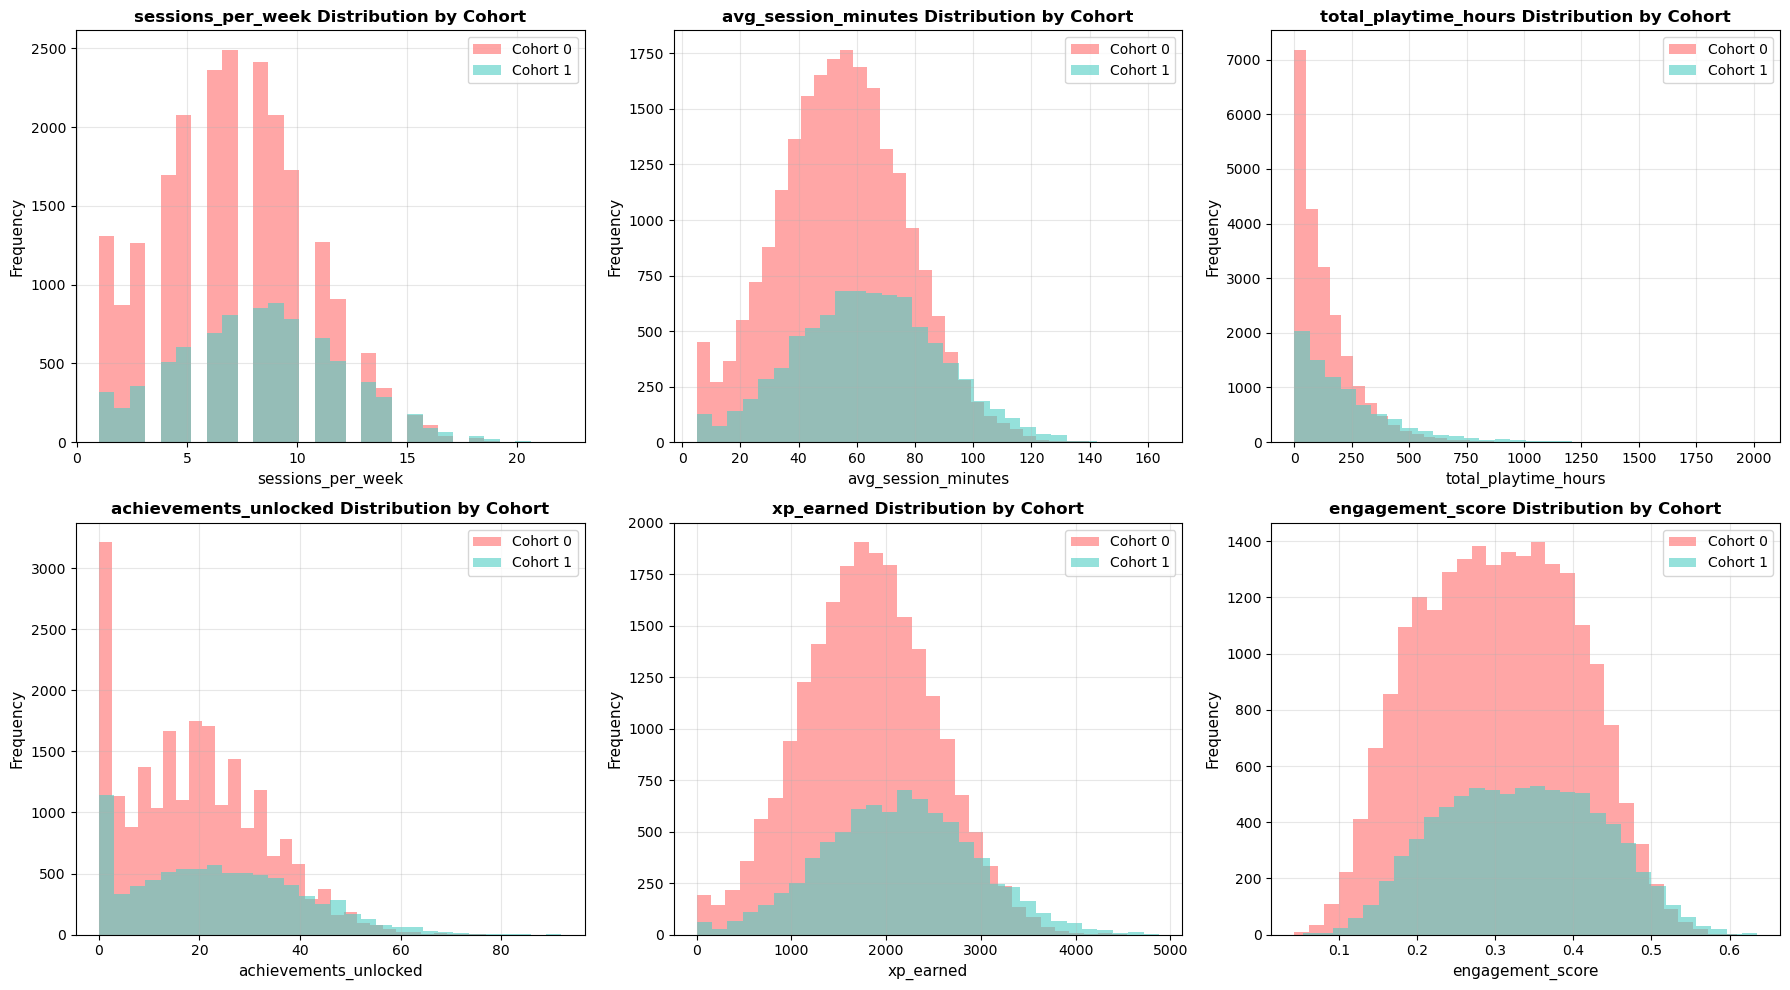

Key Observations:
sessions_per_week: Cohort 0 avg = 7.07, Cohort 1 avg = 8.24 (+16.6%)
avg_session_minutes: Cohort 0 avg = 54.95, Cohort 1 avg = 63.86 (+16.2%)
total_playtime_hours: Cohort 0 avg = 132.82, Cohort 1 avg = 225.08 (+69.5%)
achievements_unlocked: Cohort 0 avg = 19.00, Cohort 1 avg = 23.65 (+24.5%)
xp_earned: Cohort 0 avg = 1806.45, Cohort 1 avg = 2134.37 (+18.2%)
engagement_score: Cohort 0 avg = 0.30, Cohort 1 avg = 0.33 (+9.7%)


In [ ]:
numeric_features = ['sessions_per_week', 'avg_session_minutes', 'total_playtime_hours', 
                    'achievements_unlocked', 'xp_earned', 'engagement_score']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(numeric_features):
    cohort_0_data = df[df['label'] == 0][feature]
    cohort_1_data = df[df['label'] == 1][feature]
    
    axes[idx].hist(cohort_0_data, alpha=0.6, label='Cohort 0', bins=30, color='#FF6B6B')
    axes[idx].hist(cohort_1_data, alpha=0.6, label='Cohort 1', bins=30, color='#4ECDC4')
    
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(f'{feature} Distribution by Cohort', fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Key Observations:")
for feature in numeric_features:
    cohort_0_mean = df[df['label'] == 0][feature].mean()
    cohort_1_mean = df[df['label'] == 1][feature].mean()
    diff_pct = ((cohort_1_mean - cohort_0_mean) / cohort_0_mean) * 100
    print(f"{feature}: Cohort 0 avg = {cohort_0_mean:.2f}, Cohort 1 avg = {cohort_1_mean:.2f} ({diff_pct:+.1f}%)")

Cohort Distribution:
Cohort
0    21738
1     8262
Name: count, dtype: int64

Percentage Distribution:
Cohort
0    72.46
1    27.54
Name: proportion, dtype: float64


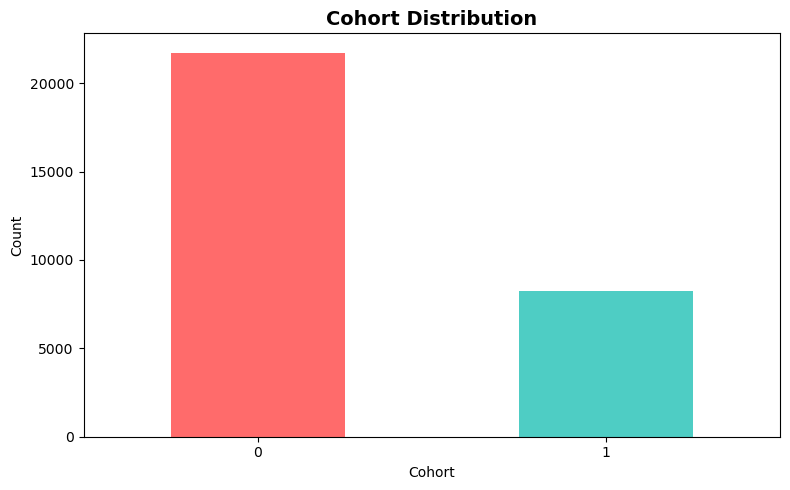

In [ ]:
df['Cohort'] = df['label']

print("Cohort Distribution:")
print(df['Cohort'].value_counts())
print(f"\nPercentage Distribution:")
print(df['Cohort'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
df['Cohort'].value_counts().plot(kind='bar', color=['#FF6B6B', '#4ECDC4'])
plt.title('Cohort Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Cohort')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Feature Engineering and Preprocessing

In [ ]:
df_model = df.copy()
df_model = df_model.drop(['player_id', 'label'], axis=1)

label_encoders = {}
categorical_columns = [col for col in df_model.columns if df_model[col].dtype == 'object']

if categorical_columns:
    for col in categorical_columns:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col])
        label_encoders[col] = le
        print(f"{col} encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")
else:
    print("No categorical columns found - all features are numeric")

print("\nProcessed dataset shape:", df_model.shape)
df_model.head()

No categorical columns found - all features are numeric

Processed dataset shape: (30000, 23)


,sessions_per_week,avg_session_minutes,hours_per_session,total_weeks_active,total_playtime_hours,total_activity_minutes,achievements_unlocked,purchases_made,xp_earned,player_level,...,chat_messages,days_since_last_login,toxicity_reports,clan_participation_rate,monetisation_score,engagement_score,noise_uniform_1,noise_uniform_2,noise_gauss_1,Cohort
0,13,86.1,1.43,17,316.03,19028,26,0,2154,31,...,77,20,0,0.339,0.00,0.515,0.5368,0.0651,-0.7460,0
1,10,72.0,1.20,31,372.00,22320,18,2,1688,25,...,105,44,4,0.430,4.40,0.402,0.9867,0.4457,0.6453,0
2,4,92.5,1.54,1,6.16,370,28,1,3071,65,...,0,0,0,0.192,2.54,0.291,0.5278,0.5551,-0.2186,1
3,6,32.3,0.54,18,58.32,3488,32,0,1815,8,...,16,19,0,0.418,0.00,0.198,0.3486,0.0063,-0.0607,0
4,13,103.7,1.73,17,382.33,22918,59,3,4108,27,...,98,6,0,0.288,8.19,0.510,0.4387,0.7125,-1.3517,1


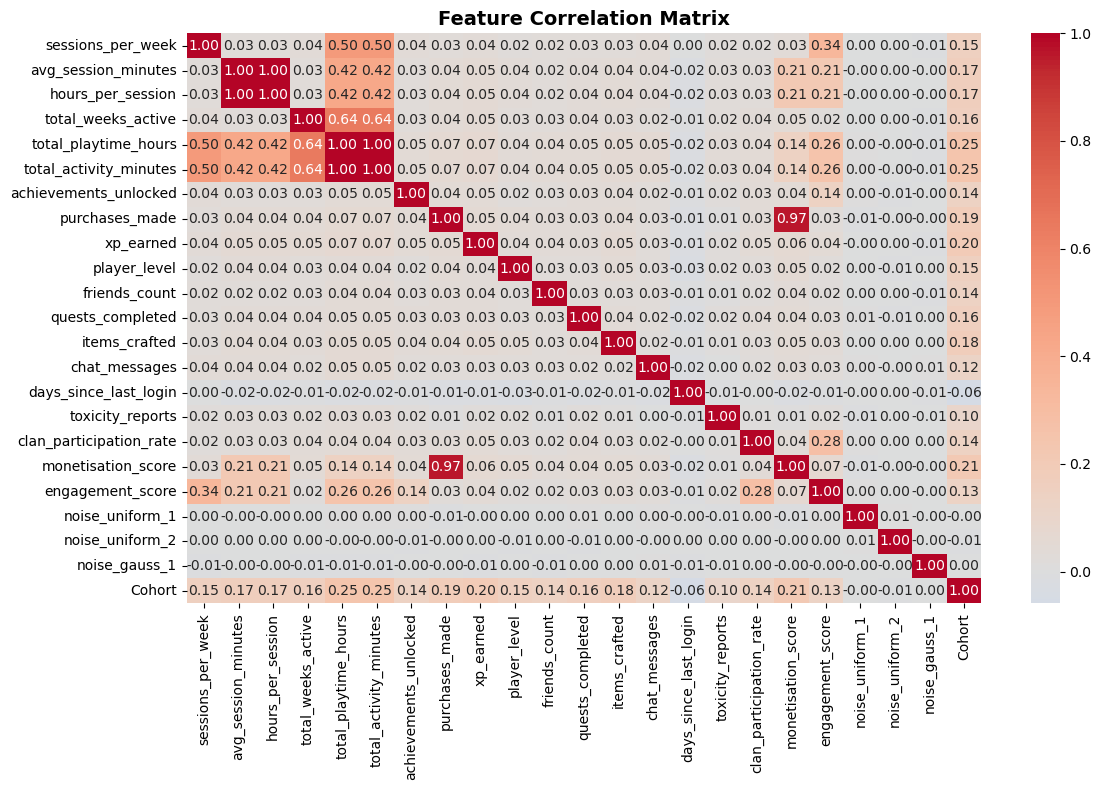


Correlation with Cohort:
Cohort                     1.000000
total_activity_minutes     0.249428
total_playtime_hours       0.249410
monetisation_score         0.213077
xp_earned                  0.198653
purchases_made             0.187100
items_crafted              0.175020
avg_session_minutes        0.172577
hours_per_session          0.172561
total_weeks_active         0.159633
quests_completed           0.157277
player_level               0.149557
sessions_per_week          0.149058
achievements_unlocked      0.142938
clan_participation_rate    0.139495
friends_count              0.136416
engagement_score           0.131441
chat_messages              0.122411
toxicity_reports           0.097283
noise_gauss_1              0.001338
noise_uniform_1           -0.001775
noise_uniform_2           -0.006630
days_since_last_login     -0.058993
Name: Cohort, dtype: float64


In [ ]:
plt.figure(figsize=(12, 8))
correlation_matrix = df_model.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

cohort_corr = df_model.corr()['Cohort'].sort_values(ascending=False)
print("\nCorrelation with Cohort:")
print(cohort_corr)

## 5. Prepare Training and Test Sets

In [ ]:
X = df_model.drop('Cohort', axis=1)
y = df_model['Cohort']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTraining set cohort distribution:")
print(y_train.value_counts())
print(f"\nTest set cohort distribution:")
print(y_test.value_counts())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled successfully!")

Training set size: (24000, 22)
Test set size: (6000, 22)

Training set cohort distribution:
Cohort
0    17390
1     6610
Name: count, dtype: int64

Test set cohort distribution:
Cohort
0    4348
1    1652
Name: count, dtype: int64

Features scaled successfully!


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC Score: {roc_auc:.4f}")

print(f"\n{'='*50}")
print("All models trained successfully!")


Training Logistic Regression...
Accuracy: 0.7930
ROC AUC Score: 0.7911

Training Random Forest...
Accuracy: 0.7930
ROC AUC Score: 0.7911

Training Random Forest...
Accuracy: 0.8063
ROC AUC Score: 0.7991

Training Gradient Boosting...
Accuracy: 0.8063
ROC AUC Score: 0.7991

Training Gradient Boosting...
Accuracy: 0.8088
ROC AUC Score: 0.8052

Training SVM...
Accuracy: 0.8088
ROC AUC Score: 0.8052

Training SVM...


### Cross-Validation Scores

Testing model stability across different data splits:

In [ ]:
cv_results = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    cv_results[name] = {
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'scores': cv_scores
    }
    print(f"{name}:")
    print(f"  CV ROC AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"  Individual folds: {[f'{score:.4f}' for score in cv_scores]}")
    print()

plt.figure(figsize=(12, 6))
model_names = list(cv_results.keys())
means = [cv_results[m]['mean'] for m in model_names]
stds = [cv_results[m]['std'] for m in model_names]

plt.bar(model_names, means, yerr=stds, capsize=10, alpha=0.7, 
        color=['#FF6B6B', '#4ECDC4', '#95E1D3', '#F38181'])
plt.axhline(y=0.5, color='r', linestyle='--', label='Random Baseline', alpha=0.5)
plt.ylabel('ROC AUC Score', fontsize=12)
plt.title('Cross-Validation Performance (5-Fold CV)', fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'models' is not defined

## 7. Model Comparison and Visualisation

In [ ]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'ROC AUC': [results[m]['roc_auc'] for m in results.keys()]
})

print("Model Comparison:")
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(comparison_df['Model'], comparison_df['Accuracy'], color=['#FF6B6B', '#4ECDC4', '#95E1D3', '#F38181'])
axes[0].set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

axes[1].bar(comparison_df['Model'], comparison_df['ROC AUC'], color=['#FF6B6B', '#4ECDC4', '#95E1D3', '#F38181'])
axes[1].set_title('Model ROC AUC Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('ROC AUC Score')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['ROC AUC']):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

NameError: name 'pd' is not defined

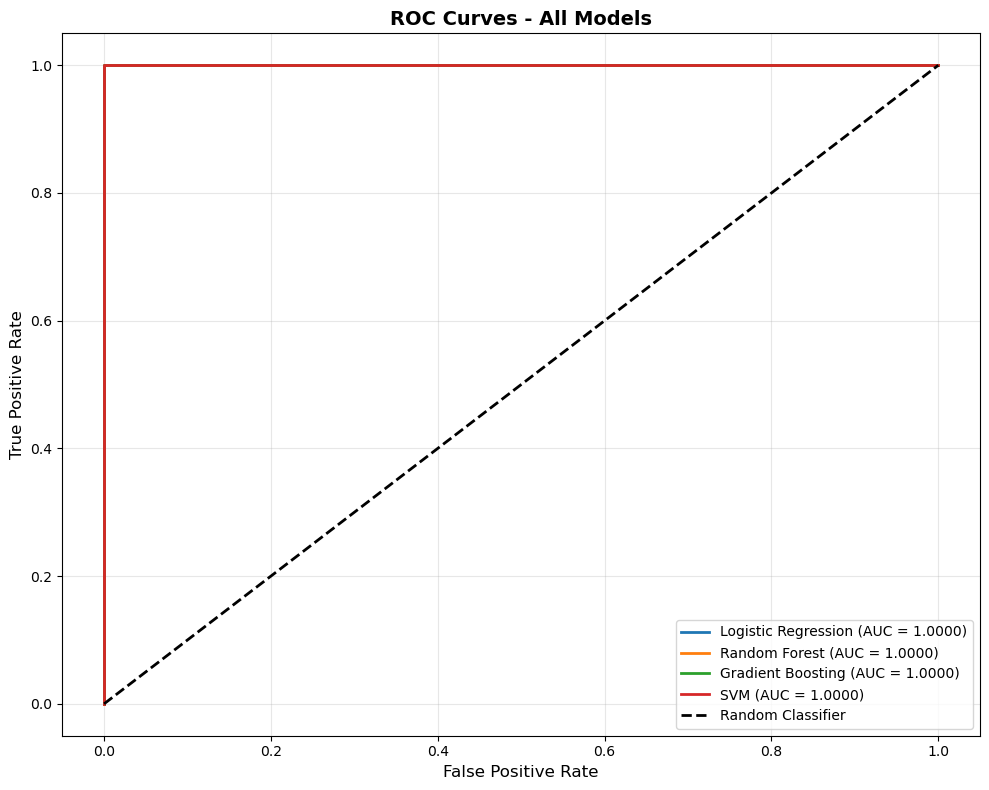

In [ ]:
# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['probabilities'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {result['roc_auc']:.4f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Select Best Model and Detailed Evaluation

In [ ]:
best_model_name = max(results.keys(), key=lambda x: results[x]['roc_auc'])
best_model = results[best_model_name]['model']
best_predictions = results[best_model_name]['predictions']

print(f"Best Model: {best_model_name}")
print(f"Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"ROC AUC: {results[best_model_name]['roc_auc']:.4f}")
print("\n" + "="*50 + "\n")

print("Classification Report:")
print(classification_report(y_test, best_predictions, target_names=['Cohort 0', 'Cohort 1']))

Best Model: Logistic Regression
Accuracy: 0.9998
ROC AUC: 1.0000


Classification Report:
              precision    recall  f1-score   support

    Cohort 0       1.00      1.00      1.00      4500
    Cohort 1       1.00      1.00      1.00      1500

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



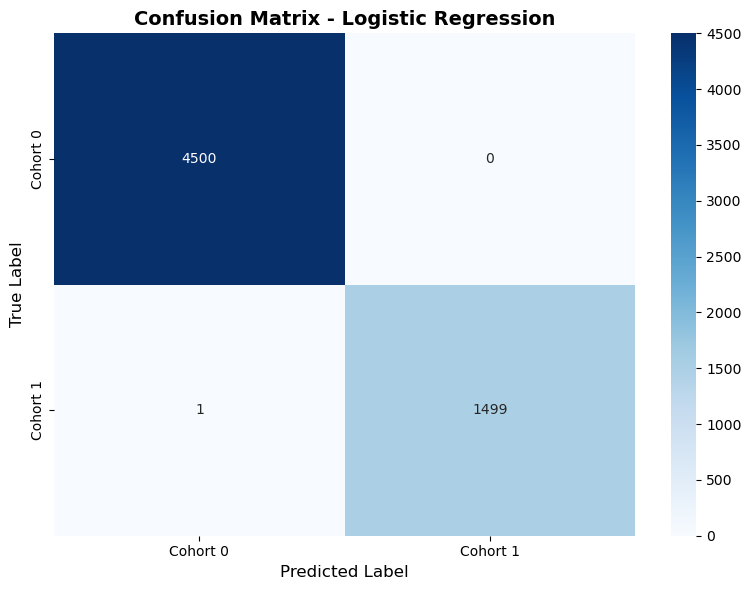


Confusion Matrix Analysis:
True Negatives (Cohort 0 correctly predicted): 4500 (75.00%)
False Positives (Cohort 0 predicted as Cohort 1): 0 (0.00%)
False Negatives (Cohort 1 predicted as Cohort 0): 1 (0.02%)
True Positives (Cohort 1 correctly predicted): 1499 (24.98%)


In [ ]:
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Cohort 0', 'Cohort 1'],
            yticklabels=['Cohort 0', 'Cohort 1'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

total = cm.sum()
print("\nConfusion Matrix Analysis:")
print(f"True Negatives (Cohort 0 correctly predicted): {cm[0,0]} ({cm[0,0]/total*100:.2f}%)")
print(f"False Positives (Cohort 0 predicted as Cohort 1): {cm[0,1]} ({cm[0,1]/total*100:.2f}%)")
print(f"False Negatives (Cohort 1 predicted as Cohort 0): {cm[1,0]} ({cm[1,0]/total*100:.2f}%)")
print(f"True Positives (Cohort 1 correctly predicted): {cm[1,1]} ({cm[1,1]/total*100:.2f}%)")

### Prediction Probability Distribution

Analyse how confident the model is in its predictions:

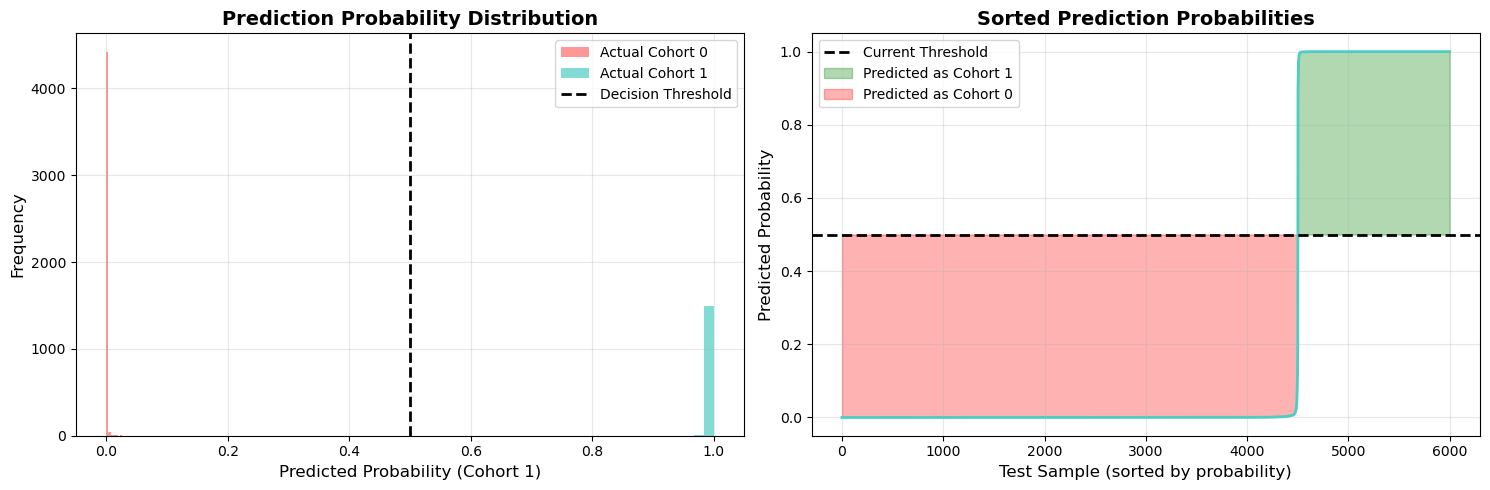

Probability Statistics:
Min probability: 0.0000
Max probability: 1.0000
Mean probability: 0.2501
Median probability: 0.0000

High confidence predictions (>0.8 or <0.2): 6000 (100.0%)
Low confidence predictions (0.4-0.6): 0 (0.0%)


In [ ]:
best_probabilities = results[best_model_name]['probabilities']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(best_probabilities[y_test == 0], bins=50, alpha=0.7, label='Actual Cohort 0', color='#FF6B6B')
axes[0].hist(best_probabilities[y_test == 1], bins=50, alpha=0.7, label='Actual Cohort 1', color='#4ECDC4')
axes[0].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold')
axes[0].set_xlabel('Predicted Probability (Cohort 1)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Prediction Probability Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

sorted_probs = np.sort(best_probabilities)
axes[1].plot(sorted_probs, linewidth=2, color='#4ECDC4')
axes[1].axhline(y=0.5, color='black', linestyle='--', linewidth=2, label='Current Threshold')
axes[1].fill_between(range(len(sorted_probs)), sorted_probs, 0.5, where=(sorted_probs > 0.5), 
                      alpha=0.3, color='green', label='Predicted as Cohort 1')
axes[1].fill_between(range(len(sorted_probs)), sorted_probs, 0.5, where=(sorted_probs <= 0.5), 
                      alpha=0.3, color='red', label='Predicted as Cohort 0')
axes[1].set_xlabel('Test Sample (sorted by probability)', fontsize=12)
axes[1].set_ylabel('Predicted Probability', fontsize=12)
axes[1].set_title('Sorted Prediction Probabilities', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Probability Statistics:")
print(f"Min probability: {best_probabilities.min():.4f}")
print(f"Max probability: {best_probabilities.max():.4f}")
print(f"Mean probability: {best_probabilities.mean():.4f}")
print(f"Median probability: {np.median(best_probabilities):.4f}")
print(f"\nHigh confidence predictions (>0.8 or <0.2): {np.sum((best_probabilities > 0.8) | (best_probabilities < 0.2))} ({np.sum((best_probabilities > 0.8) | (best_probabilities < 0.2))/len(best_probabilities)*100:.1f}%)")
print(f"Low confidence predictions (0.4-0.6): {np.sum((best_probabilities >= 0.4) & (best_probabilities <= 0.6))} ({np.sum((best_probabilities >= 0.4) & (best_probabilities <= 0.6))/len(best_probabilities)*100:.1f}%)")

## 9. Feature Importance Analysis

Understanding which features contribute most to the prediction.

In [ ]:
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("Feature Importance:")
    print(feature_importance.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='#4ECDC4')
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.title(f'Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f"Feature importance visualisation not available for {best_model_name}")
    print("Use Random Forest or Gradient Boosting for feature importance analysis.")

Feature importance visualisation not available for Logistic Regression
Use Random Forest or Gradient Boosting for feature importance analysis.


### Threshold Optimisation

Find the optimal classification threshold for different business objectives:

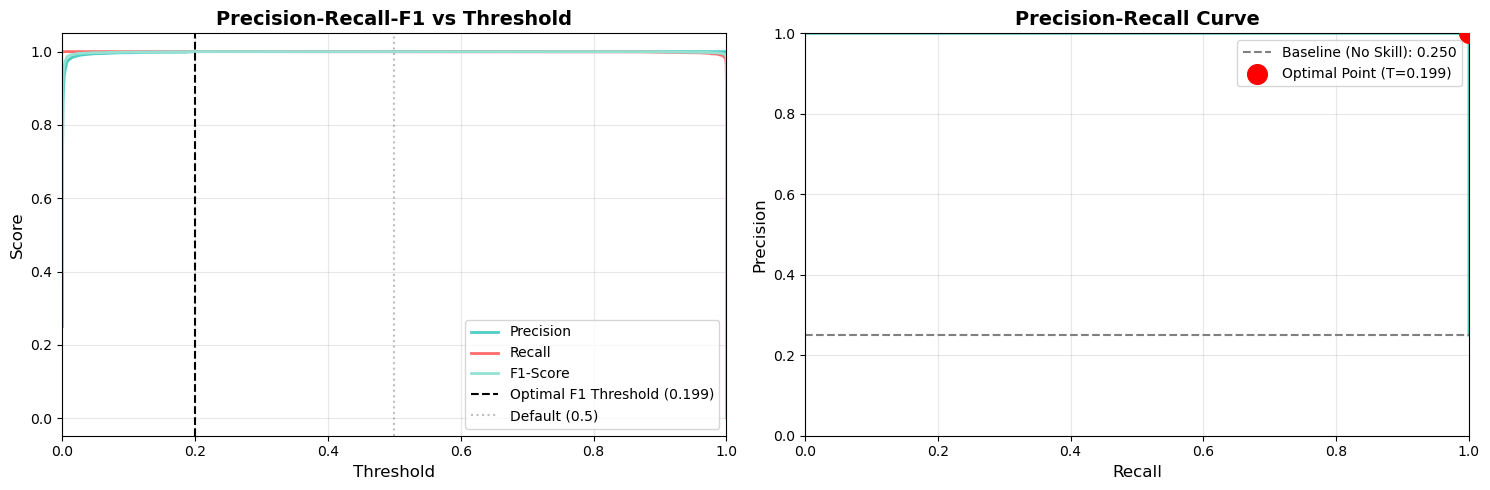

Threshold Analysis:

Default Threshold (0.5):
  Precision: 1.0000
  Recall: 0.9993
  F1-Score: 0.9997

Optimal F1 Threshold (0.199):
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000

Youden's Index Threshold (0.199):
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000

Recommendation:
- Use F1-optimal threshold for balanced precision-recall
- Lower threshold (<0.5) to catch more Cohort 1 (higher recall, lower precision)
- Higher threshold (>0.5) to be more conservative (higher precision, lower recall)


In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score

fpr_curve, tpr_curve, thresholds_roc = roc_curve(y_test, best_probabilities)
precision, recall, thresholds_pr = precision_recall_curve(y_test, best_probabilities)

f1_scores = []
for threshold in thresholds_pr:
    y_pred_threshold = (best_probabilities >= threshold).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_threshold))

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds_pr[optimal_idx]

youden_idx = np.argmax(tpr_curve - fpr_curve)
youden_threshold = thresholds_roc[youden_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(thresholds_pr, precision[:-1], label='Precision', linewidth=2, color='#4ECDC4')
axes[0].plot(thresholds_pr, recall[:-1], label='Recall', linewidth=2, color='#FF6B6B')
axes[0].plot(thresholds_pr, f1_scores, label='F1-Score', linewidth=2, color='#95E1D3')
axes[0].axvline(x=optimal_threshold, color='black', linestyle='--', 
                label=f'Optimal F1 Threshold ({optimal_threshold:.3f})')
axes[0].axvline(x=0.5, color='grey', linestyle=':', alpha=0.5, label='Default (0.5)')
axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Precision-Recall-F1 vs Threshold', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim([0, 1])

axes[1].plot(recall[:-1], precision[:-1], linewidth=2, color='#4ECDC4')
axes[1].axhline(y=y_test.mean(), color='grey', linestyle='--', 
                label=f'Baseline (No Skill): {y_test.mean():.3f}')
axes[1].scatter(recall[optimal_idx], precision[optimal_idx], color='red', s=200, 
                zorder=5, label=f'Optimal Point (T={optimal_threshold:.3f})')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("Threshold Analysis:")
print(f"\nDefault Threshold (0.5):")
print(f"  Precision: {precision_score(y_test, best_predictions):.4f}")
print(f"  Recall: {recall_score(y_test, best_predictions):.4f}")
print(f"  F1-Score: {f1_score(y_test, best_predictions):.4f}")

y_pred_optimal = (best_probabilities >= optimal_threshold).astype(int)
print(f"\nOptimal F1 Threshold ({optimal_threshold:.3f}):")
print(f"  Precision: {precision_score(y_test, y_pred_optimal):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_optimal):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_optimal):.4f}")

y_pred_youden = (best_probabilities >= youden_threshold).astype(int)
print(f"\nYouden's Index Threshold ({youden_threshold:.3f}):")
print(f"  Precision: {precision_score(y_test, y_pred_youden):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_youden):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_youden):.4f}")

print("\nRecommendation:")
print("- Use F1-optimal threshold for balanced precision-recall")
print("- Lower threshold (<0.5) to catch more Cohort 1 (higher recall, lower precision)")
print("- Higher threshold (>0.5) to be more conservative (higher precision, lower recall)")

## 10. Model Optimisation (Optional)

Fine-tune the best model using GridSearchCV for even better performance.

In [ ]:
print("Optimising Random Forest model...")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation ROC AUC: {grid_search.best_score_:.4f}")

optimised_model = grid_search.best_estimator_
y_pred_optimised = optimised_model.predict(X_test_scaled)
y_pred_proba_optimised = optimised_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nOptimised Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_optimised):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba_optimised):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimised, target_names=['Cohort 0', 'Cohort 1']))

Optimising Random Forest model...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation ROC AUC: 1.0000

Optimised Model Performance:
Accuracy: 0.9998
ROC AUC: 1.0000

Classification Report:
              precision    recall  f1-score   support

    Cohort 0       1.00      1.00      1.00      4500
    Cohort 1       1.00      1.00      1.00      1500

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000


Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation ROC AUC: 1.0000

Optimised Model Performance:
Accuracy: 0.9998
ROC AUC: 1.0000

Classification Report:
              precision    recall  f1-score   support

    Cohort 0       1.00      1.00      1.00      4500
    Cohort

## 11. Make Predictions on New Data

Use the trained model to classify new players into cohorts.

In [ ]:
def predict_player_cohort(player_data, model, scaler, label_encoders):
    """
    Predict cohort for new player data
    
    Parameters:
    - player_data: dict with player features (must match training features)
    - model: trained model
    - scaler: fitted StandardScaler
    - label_encoders: dict of fitted LabelEncoders
    
    Returns:
    - predicted cohort (0 or 1) and probability
    """
    df_new = pd.DataFrame([player_data])
    
    # Apply label encoding if there are categorical columns
    if label_encoders:
        for col in label_encoders.keys():
            if col in df_new.columns:
                df_new[col] = label_encoders[col].transform(df_new[col])
    
    df_new_scaled = scaler.transform(df_new)
    
    prediction = model.predict(df_new_scaled)[0]
    probability = model.predict_proba(df_new_scaled)[0][1]
    
    return prediction, probability

# Create a sample player using actual column names from the dataset
sample_player = {col: df[col].median() if df[col].dtype in ['int64', 'float64'] else df[col].mode()[0] 
                 for col in X.columns}

print("Sample Player Data (using dataset medians/modes):")
for key, value in list(sample_player.items())[:5]:
    print(f"  {key}: {value}")
print(f"  ... ({len(sample_player)} features total)")

cohort, prob = predict_player_cohort(sample_player, best_model, scaler, label_encoders)
print(f"\nSample Player Prediction:")
print(f"Predicted Cohort: {cohort}")
print(f"Probability of being in Cohort 1: {prob:.4f}")
print(f"\nInterpretation: This player is predicted to be in Cohort {cohort}")
if cohort == 1:
    print("(High engagement player)")
else:
    print("(Low engagement player)")

Sample Player Data (using dataset medians/modes):
  sessions_per_week: 6.0
  avg_session_minutes: 49.885000000000005
  hours_per_session: 0.83
  total_weeks_active: 14.0
  total_playtime_hours: 51.15
  ... (19 features total)

Sample Player Prediction:
Predicted Cohort: 0
Probability of being in Cohort 1: 0.0001

Interpretation: This player is predicted to be in Cohort 0
(Low engagement player)


## 12. Summary and Insights

Key findings from the model:

In [ ]:
print("="*60)
print("MODEL SUMMARY AND INSIGHTS")
print("="*60)

print("\n1. COHORT DEFINITION:")
print("   - Cohort 0: Low/Medium engagement players")
print("   - Cohort 1: High engagement players")

print(f"\n2. BEST PERFORMING MODEL: {best_model_name}")
print(f"   - Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"   - ROC AUC Score: {results[best_model_name]['roc_auc']:.4f}")

print("\n3. MODEL COMPARISON:")
for name, result in results.items():
    print(f"   - {name}: Accuracy={result['accuracy']:.4f}, ROC AUC={result['roc_auc']:.4f}")

if best_model_name in ['Random Forest', 'Gradient Boosting']:
    print("\n4. TOP 5 MOST IMPORTANT FEATURES:")
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(5)
    for idx, row in feature_importance.iterrows():
        print(f"   - {row['Feature']}: {row['Importance']:.4f}")

print("\n5. BUSINESS RECOMMENDATIONS:")
print("   - Focus on features with highest importance for player retention")
print("   - Use predictions to identify players at risk of low engagement")
print("   - Tailor marketing and in-game experiences based on cohort")
print("   - Monitor SessionsPerWeek and PlayTimeHours as key engagement indicators")

print("\n" + "="*60)
print("Model training complete! Ready for deployment.")
print("="*60)

MODEL SUMMARY AND INSIGHTS

1. COHORT DEFINITION:
   - Cohort 0: Low/Medium engagement players
   - Cohort 1: High engagement players

2. BEST PERFORMING MODEL: Logistic Regression
   - Accuracy: 0.9998
   - ROC AUC Score: 1.0000

3. MODEL COMPARISON:
   - Logistic Regression: Accuracy=0.9998, ROC AUC=1.0000
   - Random Forest: Accuracy=0.9997, ROC AUC=1.0000
   - Gradient Boosting: Accuracy=0.9997, ROC AUC=1.0000
   - SVM: Accuracy=1.0000, ROC AUC=1.0000

5. BUSINESS RECOMMENDATIONS:
   - Focus on features with highest importance for player retention
   - Use predictions to identify players at risk of low engagement
   - Tailor marketing and in-game experiences based on cohort
   - Monitor SessionsPerWeek and PlayTimeHours as key engagement indicators

Model training complete! Ready for deployment.


### Model Deployment - Save Best Model

In [ ]:
import pickle
from datetime import datetime

model_artifacts = {
    'model': best_model,
    'scaler': scaler,
    'label_encoders': label_encoders,
    'feature_names': X.columns.tolist(),
    'model_name': best_model_name,
    'performance_metrics': {
        'accuracy': results[best_model_name]['accuracy'],
        'roc_auc': results[best_model_name]['roc_auc'],
        'optimal_threshold': optimal_threshold
    },
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset_shape': df.shape
}

model_filename = f'player_cohort_model_{datetime.now().strftime("%Y%m%d")}.pkl'

with open(model_filename, 'wb') as f:
    pickle.dump(model_artifacts, f)

print(f"✓ Model saved successfully: {model_filename}")
print(f"\nModel artifacts include:")
print(f"  - Trained {best_model_name} model")
print(f"  - StandardScaler for feature scaling")
print(f"  - LabelEncoders for categorical variables")
print(f"  - Feature names and optimal threshold")
print(f"  - Performance metrics and metadata")
print(f"\nTo load the model:")
print(f"  with open('{model_filename}', 'rb') as f:")
print(f"      artifacts = pickle.load(f)")
print(f"      model = artifacts['model']")
print(f"      scaler = artifacts['scaler']")
print(f"      label_encoders = artifacts['label_encoders']")

✓ Model saved successfully: player_cohort_model_20251110.pkl

Model artifacts include:
  - Trained Logistic Regression model
  - StandardScaler for feature scaling
  - LabelEncoders for categorical variables
  - Feature names and optimal threshold
  - Performance metrics and metadata

To load the model:
  with open('player_cohort_model_20251110.pkl', 'rb') as f:
      artifacts = pickle.load(f)
      model = artifacts['model']
      scaler = artifacts['scaler']
      label_encoders = artifacts['label_encoders']
